In [1]:
from dataclasses import dataclass
from typing_extensions import Self
from typing import Callable
import numpy as np
from tqdm import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from skimage.metrics import structural_similarity as ssim
from torchvision import transforms
from torch.utils.data import DataLoader
from torch import nn
import matplotlib.pyplot as plt
import torch.optim as optim
import torch.nn.functional as F
from torch.nn.utils.rnn import pad_sequence
from tqdm import tqdm
import torch

# %matplotlib widget

from typing import Optional
import matplotlib.pyplot as plt
import torch

from pileup_ml.detectors.pixels import PixelDetector, PixelModule
from pileup_ml.pixels.hits import PixelDigiEvent
from pileup_ml.pixels.patches import (
    PixelModulePatches, PixelEventPatches, _PixelEventGrid,
    event_hits_to_patches, module_patches_to_hits, event_patches_to_hits)
from pileup_ml.compression.metrics import compare_matching_hits, compare_hit_presence

from pileup_ml.compression.base import CompressedPixelEvent
from numpy import cov, trace, iscomplexobj
from scipy.linalg import sqrtm
from torch.utils.data import random_split
from torchmetrics.regression import MeanSquaredError
from matplotlib.gridspec import GridSpec
from datetime import datetime

In [2]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

<h3>CMS pileup data compression based on VQ-VAE compression</h3>

Experiment comments and insights:
* Codebook entries from 256 vectors (rows), only approximately 120 codebook entries are used effectively based perplexity
* Reconstruction improves with bigger latent vector and num embeddings. Reducing codebook size, improves usage but not reconstruction quality
* Validation set properly works with higher beta coeficient roughly from beta in [0.2, 0.31]
* Codebook plots describe codebook variation, whether certain weights are mostly zero (grey color) and are codebook usage is not sparse (orange colors)
* Making encoded patch d > 2, we do not loose any information and perplexity does not collapse. When latent vector is flat, codebook usage is lower but not harms reconstruction

Utility function import and prepearation

In [3]:
from helpers.model_tool import ModelTool
from helpers.data_tool import CMSDataTool, \
                                CMSPlots, \
                                PixelPatchesDataset

<h3>Helper objects</h3>

In [4]:
model_tool = ModelTool()
cms_data_tool = CMSDataTool()
cms_plots = CMSPlots()

<h3>Helper constants</h3>

In [5]:
SELECTED_EVENTS = 1
EVENT_COUNT = 1
PATCH_SIZE = 8
BITS_HIT = 25 
LOG_EVERY = 15

<h3>Data loading</h3>

In [6]:
# Loading data
pixel_modules = PixelModule.read_json('/data/cern/pileup_ml/detid_info/detids_bpix.json', '/data/cern/pileup_ml/detid_info/detids_fpix.json')
pix_det = PixelDetector(pixel_modules)

events_train_all = PixelDigiEvent.read_root('/data/cern/pileup_ml/premixlib2024/0001.root', pix_det)
events_train = events_train_all[:EVENT_COUNT]

events_test_all = PixelDigiEvent.read_root('/data/cern/pileup_ml/premixlib2024/0002.root', pix_det)
events_test = events_test_all[:EVENT_COUNT]

100%|██████████| 1000/1000 [00:04<00:00, 238.91it/s]


<h3>VQ-VAE Hyperparameters</h3>

In [7]:
batch_size = 1024
beta = 0.28
# beta = 0.98

# beta = 1 0.
# beta is possible in interval [4e-3, 8e-3]

# 0.1, 0.08 - on the right track

learning_rate = 5e-4
model_param_scale = 1
# model_param_scale = 1 (right order)

num_epochs = 120
# num_epochs = 1

# input channels
channels = 1 # since grayscale images are used, we go with 1 channel images
hidden_channels = 64

# how many codebook entries
num_embeddings = 512
# num_embeddings = 32 (on track)

latent_dim = 32
# latent_dim = 64 (on track)

# Residual layer config
residual_channels = 32
residual_layers = 2

# Latent dimension size
d = 1 # adjustable encoder width for extra compression

decay = 0.99
epsilon = 1e-4
use_ema = True


In [8]:
def _get_codebook_usage(encodings: torch.tensor) -> None:
    encodings_uniq = torch.unique(encodings)
    used_encodings = len(encodings_uniq)
    usage = (used_encodings * 100) / num_embeddings
    return usage
    # print(f"Codeword utilization: {usage:.3f} %")


In [9]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [10]:
mse = MeanSquaredError()
mse = mse.to(device)

In [11]:
seed_value = 123

if device.type == "cuda":
    torch.cuda.manual_seed_all(seed_value)
else:
    torch.cuda.manual_seed(seed_value)

In [12]:
event_train = events_train[:SELECTED_EVENTS][0]

In [13]:
patch_amount = cms_data_tool._get_patch_count(event_train)
total_hit_amount = len(event_train)

print(f"Total patch amount: {patch_amount}")
print(f"Total hits: {total_hit_amount}")

Total patch amount: 15857
Total hits: 48169


<h3>Data preprocessing</h3>

<h3>Data loading</h3>

In [14]:
# Data preprocessing

transform = transforms.Compose([
    transforms.ToTensor(),
])

event_dataset = PixelPatchesDataset(event_train, PATCH_SIZE, transform)
dataset_size = len(event_dataset)

train_size = int(0.8 * dataset_size)
val_size = int(0.0005 * dataset_size)
test_size = dataset_size - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    event_dataset,
    [train_size, val_size, test_size]
)

# # Training data prepearation

train_loader = DataLoader(
    dataset=train_dataset, 
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    dataset=val_dataset, 
    shuffle=False
)

test_loader = DataLoader(
    dataset=test_dataset, 
    shuffle=False
)

print(f"Training set size: {len(train_dataset)}")
print(f"Validation set size: {len(val_dataset)}")
print(f"Test set size: {len(test_dataset)}")

Training set size: 12685
Validation set size: 7
Test set size: 3165


<h3>VAE Binary Cross Entropy loss for VQ-VAE</h3>

In [15]:
def _get_vae_loss(
    recon_x: torch.tensor, 
    x: torch.tensor
) -> float:
    recon_loss = F.binary_cross_entropy(recon_x, x, reduction="mean")
    return recon_loss

<h3>VQ-VAE model</h3>

In [16]:
# Goal of Vector Quantization is to solve posterior collapse problem

class VectorQuantizer(nn.Module):
    """
    Discretization bottleneck part of the VQ-VAE.

    Inputs:
    - n_e : number of embeddings
    - e_dim : dimension of embedding
    - beta : commitment cost used in loss term, beta * ||z_e(x)-sg[e]||^2
    """

    def __init__(self, n_e, e_dim, beta, decay, epsilon, use_ema: bool = False):
        super(VectorQuantizer, self).__init__()
        self.n_e = n_e
        self.e_dim = e_dim
        
        # commitment loss
        self.beta = beta
        self.decay = decay

        self.embedding = nn.Embedding(self.n_e, self.e_dim)
        # self.embedding.weight.data.uniform_(-1.0 / self.n_e, 1.0 / self.n_e)
        # self.embedding.weight.data.normal_()
        # self.ema_weights.data.normal_()
        # self.register_buffer("ema_weights", torch.randn(n_e, e_dim))
        self.embedding.weight.data.uniform_(
            -1 / n_e,
            1 / n_e
        )
        self.register_buffer(
            "ema_weights",
            self.embedding.weight.data.clone()
        )
        # self.ema_weights = nn.Parameter(
        #     torch.Tensor(n_e, e_dim)
        # )
        self.register_buffer('ema_cluster_size', torch.zeros(n_e))
        # if use_ema:
        #     self.embedding.weight.requires_grad_(False)
        self.codebook = self.embedding.weight
        self.decay = decay
        self.epsilon = epsilon
        self.use_ema = use_ema

    def forward(self, z, indexes: int):
        """
        Inputs the output of the encoder network z and maps it to a discrete
        one-hot vector that is the index of the closest embedding vector e_j

        z (continuous) -> z_q (discrete)

        z.shape = (batch, channel, height, width)

        quantization pipeline:

            1. get encoder input (B,C,H,W)
            2. flatten input to (B*H*W,C)

        """
        # reshape z -> (batch, height, width, channel) and flatten
        # z = z.permute(0, 2, 3, 1).contiguous()
        # z_flattened = z.view(-1, self.e_dim).contiguous()
        # distances from z to embeddings e_j (z - e)^2 = z^2 + e^2 - 2 e * z

        # NOTE: is a matrix learnable vector for learning codebook indices. 
        # Euclidean distance for finding closest codebooks
        
        d = torch.sum(z ** 2, dim=1, keepdim=True) + \
            torch.sum(self.codebook**2, dim=1) - 2 * \
            torch.matmul(z, self.codebook.t())
            
        # Result -> d gets dimensions from matrix torch.matmul(z_flattened, self.embedding.weight.t())
        # embedding weight t is defined by num_embeddings, latent_dim
        # --------------------
            
        # find closest encodings
        min_encoding_indices = torch.argmin(d, dim=1).unsqueeze(1)
        
        min_encodings = torch.zeros(
            min_encoding_indices.shape[0], self.n_e
        ).to(device)
        
        # perform one hot encoding
        min_encodings.scatter_(1, min_encoding_indices, 1)

        # NOTE: selects weights form embedding weight and puts them based on one hot encoding
        z_q = torch.matmul(min_encodings, self.codebook).view(z.shape)
        
        # beta - commitment cost used in loss term
        if self.use_ema and self.training:
            
            # List that holds all the averaged points
            # shrinks passed clusters and gives more attention to the recent ema_cluster_size * decay
            # decay helps to determina which parts contribute more
            
            # Required for making sure that gradients are not used
            self.ema_cluster_size.mul_(self.decay).add_(
                (1 - self.decay) * torch.sum(min_encodings, 0)
            )
            
            # n_e * epsilon ensures that each cluster has some size and no 0
            # dat normalization
            # total_cluster_size = self.ema_cluster_size.sum(dim=-1, keepdim=True)
            total_cluster_size = self.ema_cluster_size.sum()
            
            # normalizes data from 0 to 1
            self.ema_cluster_size = (
                (self.ema_cluster_size + self.epsilon)
                / (total_cluster_size + self.n_e * self.epsilon)
                * total_cluster_size
            )
            dw = torch.matmul(min_encodings.t(), z.detach())
            
            self.ema_weights.mul_(self.decay).add_((1-self.decay) * dw)

            # self.codebook.copy_(
            #     self.ema_weights /
            #     self.ema_cluster_size.unsqueeze(1)
            # )
            self.codebook = nn.Parameter(self.ema_weights / self.ema_cluster_size.unsqueeze(1))
                
            # self.ema_weights.data = self.ema_weights * self.decay + (1 - self.decay) * dw
            # self.embedding.weight.data = self.ema_weights / self.ema_cluster_size.unsqueeze(1)
        
        # compute loss for embedding
        vq_loss = torch.mean((z_q.detach() - z)**2)
        
        if self.use_ema:
            loss = (
                self.beta * vq_loss
            )
        else:
            commitment_loss = torch.mean((z_q - z.detach())**2)
            loss = (
                vq_loss + self.beta * commitment_loss
            )
        # preserve gradients with preservation trick. Allows gradients to exist
        # (z_q - z.detach() )- is like a constant

        # We make quantized latent space vector to get closer to the encoder output
        # we highliht the codewords and gradually each epoch we force neaigoboring pixels
        # to be associating with cendroids
        z_q = z + (z_q - z).detach()

        # e_mean - embeddings mean
        # perplexity - average of weights of probabilities
        e_mean = torch.mean(min_encodings, dim=0)
        
        # Measures how many codebook vectors are beeing used
        perplexity = torch.exp(-torch.sum(e_mean * torch.log(e_mean + 1e-10)))
        
        z_q = z_q.reshape(-1, indexes, self.e_dim)
        
        return loss, z_q, perplexity, min_encodings, min_encoding_indices, self.codebook

In [17]:
class ResidualLayer(nn.Module):
    """
    One residual layer inputs:
    - in_dim : the input dimension
    - h_dim : the hidden layer dimension
    - res_h_dim : the hidden dimension of the residual block
    """

    def __init__(self, in_dim, h_dim, res_h_dim, slope):
        super(ResidualLayer, self).__init__()
        self.res_block = nn.Sequential(
            nn.LeakyReLU(negative_slope=slope, inplace=True),
            nn.Conv2d(in_dim, res_h_dim, kernel_size=3,
                      stride=1, padding=1, bias=False),
            nn.LeakyReLU(negative_slope=slope, inplace=True),
            nn.Conv2d(res_h_dim, h_dim, kernel_size=1,
                      stride=1, bias=False)
        )

    def forward(self, x):
        x = x + self.res_block(x)
        return x


class ResidualStack(nn.Module):
    """
    A stack of residual layers inputs:
    - in_dim : the input dimension
    - h_dim : the hidden layer dimension
    - res_h_dim : the hidden dimension of the residual block
    - n_res_layers : number of layers to stack
    """

    def __init__(self, in_dim, h_dim, res_h_dim, n_res_layers, slope):
        super(ResidualStack, self).__init__()
        self.n_res_layers = n_res_layers
        self.slope = slope
        self.stack = nn.ModuleList(
            [
                ResidualLayer(in_dim, h_dim, res_h_dim, slope)
                for _ in range(n_res_layers)
            ])

    def forward(self, x):
        for layer in self.stack:
            x = layer(x)
        x = F.relu(x)
        return x

In [18]:
# TODO: think about it later
class AbstractModule(nn.Module):
    
    def __init__(self) -> None:
        super().__init__()
    
    def forward(self, x: torch.tensor) -> None:
        raise NotImplemented

In [19]:
# TODO: test with 2 x 2 encoded patch

class EncoderInput(AbstractModule):
    
    # NOTE: encoder_features - from convolution network
    """
    indexes: int - how many codebook indexes could an encoded patch have    
    encoder_features: int - how many features are in encoder convolution output 
    
    """
    def __init__(self, indexes: int, slope: np.float64, latent_dim: int, encoder_features: int = 4) -> None:
        super().__init__()
        
        # TODO: in_features need to come from encoder conv network
        self.encoder_features = encoder_features
        self.layers = nn.Sequential(
            nn.Linear(in_features=encoder_features, out_features=indexes),
            nn.BatchNorm1d(latent_dim),
            nn.LeakyReLU(slope)
        )
        
    def forward(self, x: torch.tensor) -> None:
        b, c, w, h = x.shape
        x_flattened = x.reshape(b, c, w * h)
        x_output = self.layers(x_flattened)
        (b, c, w) = x_output.shape
        x_output_flattened = x_output.reshape(b * w, c)
        return x_output_flattened.contiguous()
    

class DecoderInput(AbstractModule):
    
    # NOTE: decoder_features - dinamically add required feature count for decoder
    
    """
    d: int - how many indexes could an encoded patch have
    decoder_features: int - how many features could a decoder convolution network have
    """
    
    def __init__(
        self, 
        indexes: int, 
        slope: np.float64, 
        decoder_features: int = 4,
    ) -> None:
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(in_features=indexes, out_features=decoder_features),
            nn.BatchNorm1d(latent_dim),
            nn.LeakyReLU(slope)
        )
        self.decoder_features = decoder_features
        
    def forward(self, x: torch.tensor) -> None:
        (b, w, c) = x.shape
        x = x.reshape(b, c, w)
        dec_out = self.layers(x)
        
        dec_out = dec_out.reshape(
            b,
            c,
            self.decoder_features//2,
            self.decoder_features//2
        )
        return dec_out
    

In [20]:
# Comments
# kernel_size = 4 - preserves spatial repesentations (coordinates)
class VQVAE(nn.Module):
    
    def __init__(
        self, 
        hidden_channels: int, 
        kernel_size: int, 
        slope: float,
        res_h_dim: int,
        n_res_layers: int,
        d: int,
        residual_slope: float = 0.08,
        use_ema: bool = False
    ) -> None:
        super().__init__()
        
        self.encoder = nn.Sequential(   
            nn.Conv2d(channels, hidden_channels, kernel_size=kernel_size, stride=2, padding=1, bias=False),  
            nn.GroupNorm(8, hidden_channels),
            nn.LeakyReLU(slope),
            nn.Conv2d(hidden_channels, hidden_channels * 2, kernel_size=kernel_size, stride=2, padding=1, bias=False),
            nn.GroupNorm(8, hidden_channels * 2),
            nn.LeakyReLU(slope),            
            nn.Conv2d(hidden_channels * 2, latent_dim, kernel_size=kernel_size-1, stride=1, padding=1, bias=False),
            nn.GroupNorm(8, latent_dim),
            ResidualStack(latent_dim, latent_dim, res_h_dim, n_res_layers, residual_slope)
        )
        
        # fully connected layer for encoder input
        self.fc_encoder_input = EncoderInput(indexes=d, slope=slope, latent_dim=latent_dim)     
        
        self.vq_layer = VectorQuantizer(num_embeddings, latent_dim, beta, decay, epsilon, use_ema=use_ema)
        
        # fully connected layer for vq input
        self.fc_decoder_input = DecoderInput(indexes=d, slope=slope)
        
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(latent_dim, hidden_channels * 2, kernel_size=kernel_size - 1, stride=1, padding=1, bias=False),
            nn.GroupNorm(8, hidden_channels * 2),
            ResidualStack(hidden_channels * 2, hidden_channels * 2, res_h_dim, n_res_layers, residual_slope),
            nn.ConvTranspose2d(hidden_channels * 2, hidden_channels, kernel_size=kernel_size, stride=2, padding=1, bias=False),
            nn.GroupNorm(8, hidden_channels),
            nn.LeakyReLU(slope),
            nn.ConvTranspose2d(hidden_channels, channels, kernel_size=kernel_size, stride=2, padding=1, bias=False),
            nn.Sigmoid()
        )

        
    def forward(self, x, indexes):
        encoder_output = self.encoder(x)
        
        z = self.fc_encoder_input(encoder_output)
        # (b, c, d) -> (b * d, c)
        
        (
            recon_loss, 
            z_q, 
            perplexity, 
            min_encodings, 
            min_encoding_indices, 
            codebook
        ) = self.vq_layer(z, indexes)
        
        usage = _get_codebook_usage(min_encoding_indices)
        
        output_decoder_input = self.fc_decoder_input(z_q)
        
        output = self.decoder(output_decoder_input)
        
        return (
            output, 
            codebook, 
            z_q,
            perplexity, 
            recon_loss,
            usage,
            min_encoding_indices
        )

In [21]:
model = VQVAE(
    hidden_channels=hidden_channels, 
    kernel_size = 4,
    slope=0.1,
    d=d, # encoded patch indexes
    n_res_layers=residual_layers, # residual hidden layers
    res_h_dim=residual_channels, # residual hidden channels,
    use_ema=use_ema
).to(device)

optimizer = optim.Adam(
    model.parameters(), 
    lr=learning_rate, 
    amsgrad=True
)

<h3>VQ-VAE training loop</h3>

Epoch 1/120: 100%|██████████| 13/13 [00:00<00:00, 40.88it/s, Loss (BCE + VQ)=0.0977]

Epoch [1/120] summary:Average Loss: VQ + BCE = 0.2277, Average loss: BCE = 0.1981MSE = 0.04450890973496895avg_perplexity = 77.09424121563251
Average validation set BCE loss: 0.11108294927648135
Before compression (Training)
Shape: (397, 8, 8)


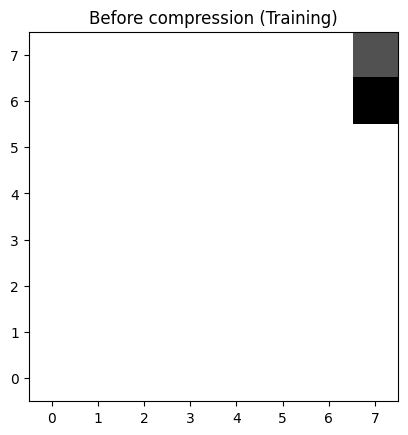

After compression (Training)
Shape: (1, 8, 8)
Codebook usage percentage (Training): 18.164 %


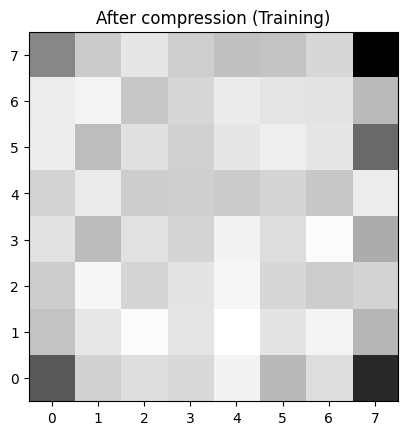

Epoch 2/120: 100%|██████████| 13/13 [00:00<00:00, 122.97it/s, Loss (BCE + VQ)=0.0817]


Epoch [2/120] summary:Average Loss: VQ + BCE = 0.0899, Average loss: BCE = 0.0839MSE = 0.008343316614627838avg_perplexity = 74.17664982722356
Average validation set BCE loss: 0.10350629048688072


Epoch 3/120: 100%|██████████| 13/13 [00:00<00:00, 126.48it/s, Loss (BCE + VQ)=0.0765]


Epoch [3/120] summary:Average Loss: VQ + BCE = 0.0824, Average loss: BCE = 0.0782MSE = 0.008050989896918718avg_perplexity = 73.90721071683444
Average validation set BCE loss: 0.09836956539324351


Epoch 4/120: 100%|██████████| 13/13 [00:00<00:00, 124.34it/s, Loss (BCE + VQ)=0.0739]


...

Epoch [14/120] summary:Average Loss: VQ + BCE = 0.0554, Average loss: BCE = 0.0493MSE = 0.004768169628312955avg_perplexity = 85.12200986422025
Average validation set BCE loss: 0.08019843378237315


Epoch 15/120: 100%|██████████| 13/13 [00:00<00:00, 126.89it/s, Loss (BCE + VQ)=0.0583]


Epoch [15/120] summary:Average Loss: VQ + BCE = 0.0554, Average loss: BCE = 0.0491MSE = 0.004744202579156711avg_perplexity = 86.59995563213641
Average validation set BCE loss: 0.07843195434127535


Epoch 16/120: 100%|██████████| 13/13 [00:00<00:00, 126.12it/s, Loss (BCE + VQ)=0.0534]


Epoch [16/120] summary:Average Loss: VQ + BCE = 0.0548, Average loss: BCE = 0.0485MSE = 0.004628773277195601avg_perplexity = 86.44726210374098
Average validation set BCE loss: 0.07708827273121902
Before compression (Training)
Shape: (397, 8, 8)


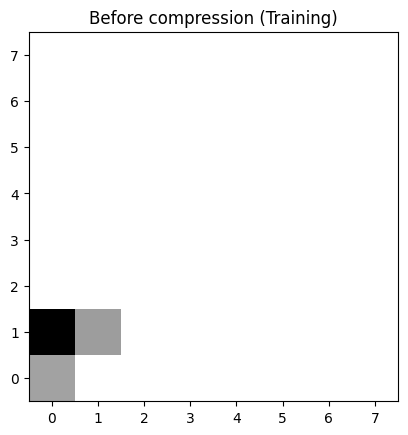

After compression (Training)
Shape: (1, 8, 8)
Codebook usage percentage (Training): 18.359 %


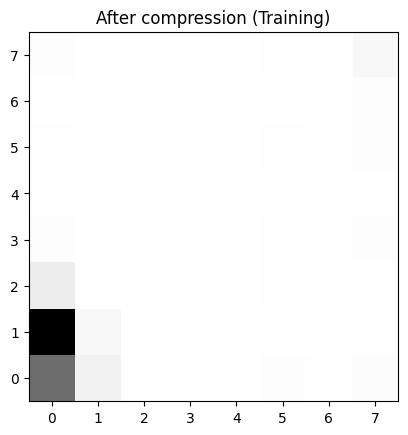

Epoch 17/120: 100%|██████████| 13/13 [00:00<00:00, 120.65it/s, Loss (BCE + VQ)=0.0578]


Epoch [17/120] summary:Average Loss: VQ + BCE = 0.0548, Average loss: BCE = 0.0484MSE = 0.004650093364314391avg_perplexity = 86.95740626408504
Average validation set BCE loss: 0.07604624623698848


Epoch 18/120: 100%|██████████| 13/13 [00:00<00:00, 125.41it/s, Loss (BCE + VQ)=0.055]


Epoch [18/120] summary:Average Loss: VQ + BCE = 0.0546, Average loss: BCE = 0.0480MSE = 0.0045952323394326065avg_perplexity = 87.49627978985126
Average validation set BCE loss: 0.07549894388232913


Epoch 19/120: 100%|██████████| 13/13 [00:00<00:00, 119.09it/s, Loss (BCE + VQ)=0.0525]


...

Epoch [29/120] summary:Average Loss: VQ + BCE = 0.0539, Average loss: BCE = 0.0464MSE = 0.004495056990820628avg_perplexity = 90.49982628455528
Average validation set BCE loss: 0.06977110409310885


Epoch 30/120: 100%|██████████| 13/13 [00:00<00:00, 122.44it/s, Loss (BCE + VQ)=0.05]  


Epoch [30/120] summary:Average Loss: VQ + BCE = 0.0536, Average loss: BCE = 0.0461MSE = 0.00444274116307497avg_perplexity = 90.08882199800931
Average validation set BCE loss: 0.06975134728210312


Epoch 31/120: 100%|██████████| 13/13 [00:00<00:00, 123.71it/s, Loss (BCE + VQ)=0.0579]


Epoch [31/120] summary:Average Loss: VQ + BCE = 0.0540, Average loss: BCE = 0.0464MSE = 0.004479316528886557avg_perplexity = 90.55544104942909
Average validation set BCE loss: 0.07012471184134483
Before compression (Training)
Shape: (397, 8, 8)


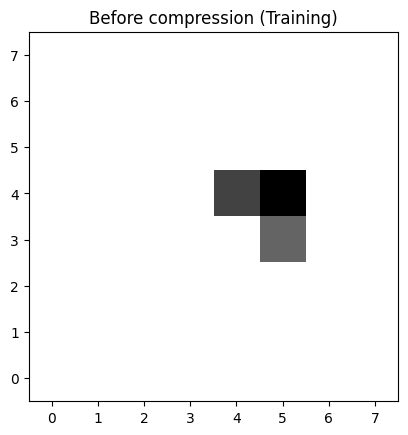

After compression (Training)
Shape: (1, 8, 8)
Codebook usage percentage (Training): 19.531 %


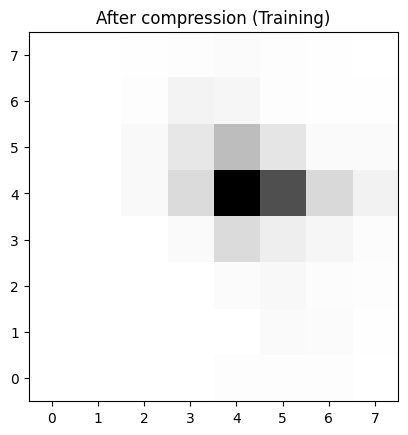

Epoch 32/120: 100%|██████████| 13/13 [00:00<00:00, 121.24it/s, Loss (BCE + VQ)=0.0502]


Epoch [32/120] summary:Average Loss: VQ + BCE = 0.0536, Average loss: BCE = 0.0459MSE = 0.004408374572029481avg_perplexity = 90.65174161470853
Average validation set BCE loss: 0.07002793651606355


Epoch 33/120: 100%|██████████| 13/13 [00:00<00:00, 125.28it/s, Loss (BCE + VQ)=0.0551]


Epoch [33/120] summary:Average Loss: VQ + BCE = 0.0536, Average loss: BCE = 0.0460MSE = 0.00446778847477757avg_perplexity = 90.67388387826773
Average validation set BCE loss: 0.06828817432480198


Epoch 34/120: 100%|██████████| 13/13 [00:00<00:00, 124.09it/s, Loss (BCE + VQ)=0.0567]


...

Epoch [44/120] summary:Average Loss: VQ + BCE = 0.0532, Average loss: BCE = 0.0455MSE = 0.004411993906475031avg_perplexity = 91.04122337928185
Average validation set BCE loss: 0.06651954139981951


Epoch 45/120: 100%|██████████| 13/13 [00:00<00:00, 125.74it/s, Loss (BCE + VQ)=0.0597]


Epoch [45/120] summary:Average Loss: VQ + BCE = 0.0532, Average loss: BCE = 0.0455MSE = 0.004463143575076873avg_perplexity = 91.39094836895282
Average validation set BCE loss: 0.06539829687348434


Epoch 46/120: 100%|██████████| 13/13 [00:00<00:00, 125.83it/s, Loss (BCE + VQ)=0.0519]


Epoch [46/120] summary:Average Loss: VQ + BCE = 0.0530, Average loss: BCE = 0.0453MSE = 0.004403140789900835avg_perplexity = 91.86551431509164
Average validation set BCE loss: 0.06515586083488804
Before compression (Training)
Shape: (397, 8, 8)


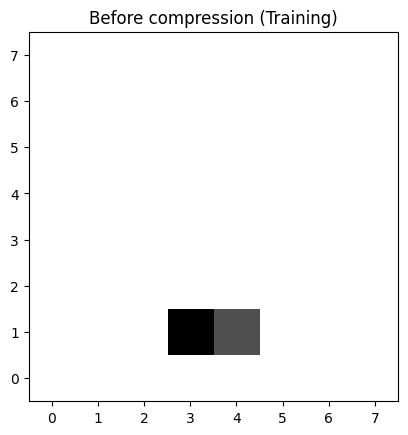

After compression (Training)
Shape: (1, 8, 8)
Codebook usage percentage (Training): 19.922 %


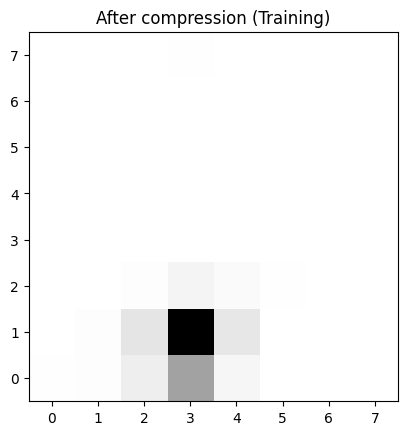

Epoch 47/120: 100%|██████████| 13/13 [00:00<00:00, 120.94it/s, Loss (BCE + VQ)=0.052] 


Epoch [47/120] summary:Average Loss: VQ + BCE = 0.0530, Average loss: BCE = 0.0453MSE = 0.004410829001034682avg_perplexity = 91.2260982806866
Average validation set BCE loss: 0.06487827668232578


Epoch 48/120: 100%|██████████| 13/13 [00:00<00:00, 122.88it/s, Loss (BCE + VQ)=0.0517]


Epoch [48/120] summary:Average Loss: VQ + BCE = 0.0529, Average loss: BCE = 0.0453MSE = 0.00440827334442964avg_perplexity = 91.93640899658203
Average validation set BCE loss: 0.0648421049118042


Epoch 49/120: 100%|██████████| 13/13 [00:00<00:00, 123.69it/s, Loss (BCE + VQ)=0.0538]


...

Epoch [59/120] summary:Average Loss: VQ + BCE = 0.0528, Average loss: BCE = 0.0450MSE = 0.004423961186638245avg_perplexity = 92.28426067645734
Average validation set BCE loss: 0.06301639761243548


Epoch 60/120: 100%|██████████| 13/13 [00:00<00:00, 122.98it/s, Loss (BCE + VQ)=0.0504]


Epoch [60/120] summary:Average Loss: VQ + BCE = 0.0526, Average loss: BCE = 0.0448MSE = 0.004402693934165514avg_perplexity = 91.62016765887921
Average validation set BCE loss: 0.06353720304157053


Epoch 61/120: 100%|██████████| 13/13 [00:00<00:00, 127.15it/s, Loss (BCE + VQ)=0.0537]


Epoch [61/120] summary:Average Loss: VQ + BCE = 0.0527, Average loss: BCE = 0.0450MSE = 0.004390785291504402avg_perplexity = 91.86917055570163
Average validation set BCE loss: 0.06357614030795437
Before compression (Training)
Shape: (397, 8, 8)


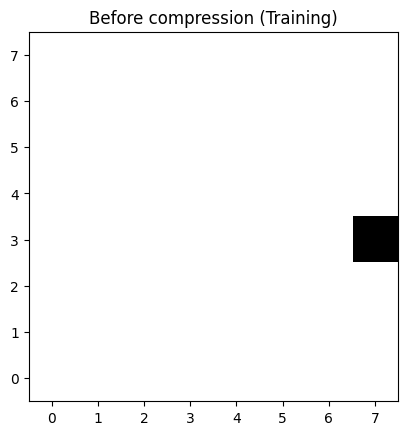

After compression (Training)
Shape: (1, 8, 8)
Codebook usage percentage (Training): 19.336 %


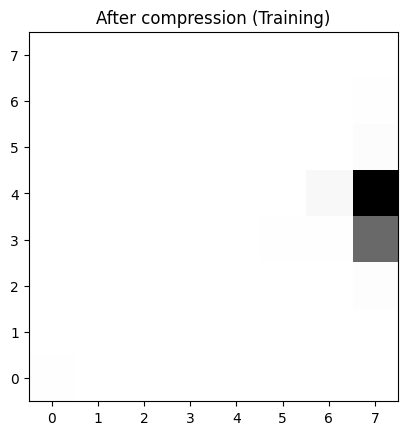

Epoch 62/120: 100%|██████████| 13/13 [00:00<00:00, 126.42it/s, Loss (BCE + VQ)=0.0498]


Epoch [62/120] summary:Average Loss: VQ + BCE = 0.0524, Average loss: BCE = 0.0447MSE = 0.00436988420999394avg_perplexity = 92.26879002497746
Average validation set BCE loss: 0.06368046067655087


Epoch 63/120: 100%|██████████| 13/13 [00:00<00:00, 125.30it/s, Loss (BCE + VQ)=0.0545]


Epoch [63/120] summary:Average Loss: VQ + BCE = 0.0525, Average loss: BCE = 0.0448MSE = 0.004372074591139188avg_perplexity = 91.97255354661208
Average validation set BCE loss: 0.06307863364262241


Epoch 64/120: 100%|██████████| 13/13 [00:00<00:00, 124.08it/s, Loss (BCE + VQ)=0.0523]


...

Epoch [74/120] summary:Average Loss: VQ + BCE = 0.0522, Average loss: BCE = 0.0446MSE = 0.004373950167344167avg_perplexity = 92.1270264845628
Average validation set BCE loss: 0.06225309866879668


Epoch 75/120: 100%|██████████| 13/13 [00:00<00:00, 125.52it/s, Loss (BCE + VQ)=0.0547]


Epoch [75/120] summary:Average Loss: VQ + BCE = 0.0524, Average loss: BCE = 0.0448MSE = 0.004416623331892949avg_perplexity = 92.07954524113582
Average validation set BCE loss: 0.06154499548886504


Epoch 76/120: 100%|██████████| 13/13 [00:00<00:00, 125.45it/s, Loss (BCE + VQ)=0.0569]


Epoch [76/120] summary:Average Loss: VQ + BCE = 0.0526, Average loss: BCE = 0.0448MSE = 0.004434165831368703avg_perplexity = 91.92261739877554
Average validation set BCE loss: 0.06292563384132725
Before compression (Training)
Shape: (397, 8, 8)


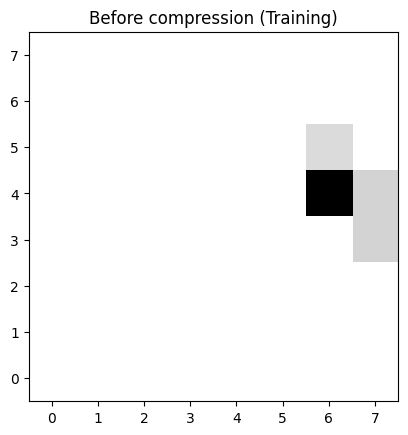

After compression (Training)
Shape: (1, 8, 8)
Codebook usage percentage (Training): 19.727 %


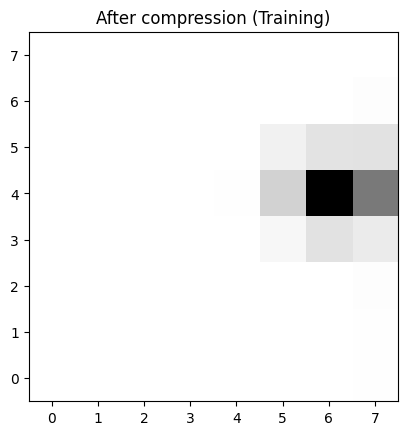

Epoch 77/120: 100%|██████████| 13/13 [00:00<00:00, 122.85it/s, Loss (BCE + VQ)=0.0511]


Epoch [77/120] summary:Average Loss: VQ + BCE = 0.0522, Average loss: BCE = 0.0445MSE = 0.004374301061034203avg_perplexity = 92.3243167583759
Average validation set BCE loss: 0.06087680613355977


Epoch 78/120: 100%|██████████| 13/13 [00:00<00:00, 125.01it/s, Loss (BCE + VQ)=0.0537]


Epoch [78/120] summary:Average Loss: VQ + BCE = 0.0522, Average loss: BCE = 0.0446MSE = 0.004381999122695281avg_perplexity = 91.60647817758414
Average validation set BCE loss: 0.061988166134272306


Epoch 79/120: 100%|██████████| 13/13 [00:00<00:00, 127.22it/s, Loss (BCE + VQ)=0.054]


...

Epoch [89/120] summary:Average Loss: VQ + BCE = 0.0521, Average loss: BCE = 0.0445MSE = 0.004388876975728915avg_perplexity = 92.23531458928035
Average validation set BCE loss: 0.06199388099568231


Epoch 90/120: 100%|██████████| 13/13 [00:00<00:00, 132.98it/s, Loss (BCE + VQ)=0.0509]


Epoch [90/120] summary:Average Loss: VQ + BCE = 0.0521, Average loss: BCE = 0.0444MSE = 0.0043549130563266avg_perplexity = 92.66987609863281
Average validation set BCE loss: 0.062358607671090534


Epoch 91/120: 100%|██████████| 13/13 [00:00<00:00, 129.44it/s, Loss (BCE + VQ)=0.0543]


Epoch [91/120] summary:Average Loss: VQ + BCE = 0.0522, Average loss: BCE = 0.0446MSE = 0.004391901947271366avg_perplexity = 92.56547722449669
Average validation set BCE loss: 0.06310980128390449
Before compression (Training)
Shape: (397, 8, 8)


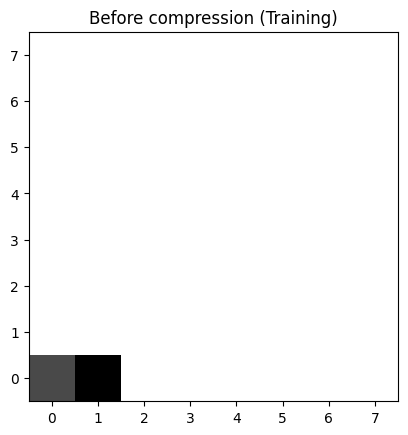

After compression (Training)
Shape: (1, 8, 8)
Codebook usage percentage (Training): 20.508 %


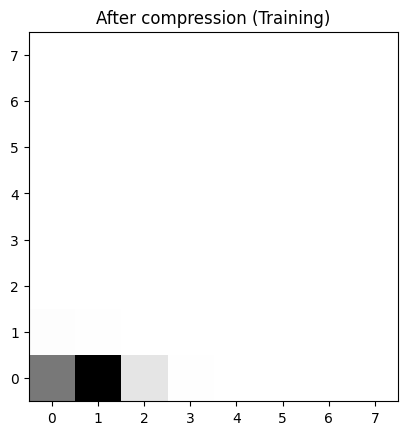

Epoch 92/120: 100%|██████████| 13/13 [00:00<00:00, 127.59it/s, Loss (BCE + VQ)=0.0481]


Epoch [92/120] summary:Average Loss: VQ + BCE = 0.0520, Average loss: BCE = 0.0443MSE = 0.004356625740631268avg_perplexity = 92.62589733417218
Average validation set BCE loss: 0.06262617505022458


Epoch 93/120: 100%|██████████| 13/13 [00:00<00:00, 122.52it/s, Loss (BCE + VQ)=0.0519]


Epoch [93/120] summary:Average Loss: VQ + BCE = 0.0519, Average loss: BCE = 0.0444MSE = 0.00434829556168272avg_perplexity = 92.71882805457481
Average validation set BCE loss: 0.06227511167526245


Epoch 94/120: 100%|██████████| 13/13 [00:00<00:00, 125.94it/s, Loss (BCE + VQ)=0.054]


...

Epoch [104/120] summary:Average Loss: VQ + BCE = 0.0519, Average loss: BCE = 0.0444MSE = 0.004370634050036852avg_perplexity = 92.8291766826923
Average validation set BCE loss: 0.0633059021617685


Epoch 105/120: 100%|██████████| 13/13 [00:00<00:00, 122.28it/s, Loss (BCE + VQ)=0.0517]


Epoch [105/120] summary:Average Loss: VQ + BCE = 0.0520, Average loss: BCE = 0.0444MSE = 0.004379076274255147avg_perplexity = 92.87110548753004
Average validation set BCE loss: 0.0619435648300818


Epoch 106/120: 100%|██████████| 13/13 [00:00<00:00, 124.50it/s, Loss (BCE + VQ)=0.0523]


Epoch [106/120] summary:Average Loss: VQ + BCE = 0.0520, Average loss: BCE = 0.0445MSE = 0.004392626193853525avg_perplexity = 93.08746924767128
Average validation set BCE loss: 0.06374828144907951
Before compression (Training)
Shape: (397, 8, 8)


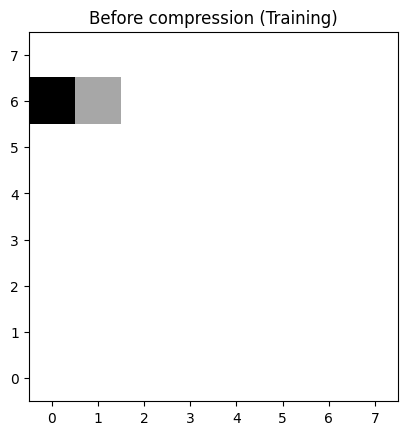

After compression (Training)
Shape: (1, 8, 8)
Codebook usage percentage (Training): 20.703 %


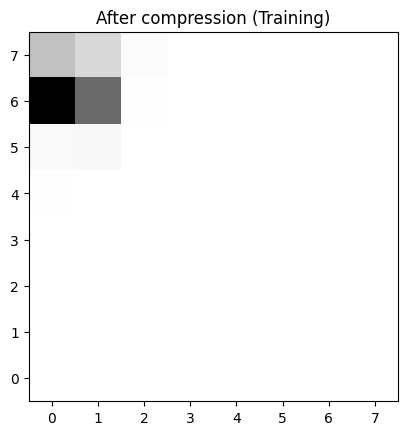

Epoch 107/120: 100%|██████████| 13/13 [00:00<00:00, 123.86it/s, Loss (BCE + VQ)=0.052]


Epoch [107/120] summary:Average Loss: VQ + BCE = 0.0520, Average loss: BCE = 0.0444MSE = 0.0043763184848313146avg_perplexity = 93.15686387282152
Average validation set BCE loss: 0.0629134683736733


Epoch 108/120: 100%|██████████| 13/13 [00:00<00:00, 122.91it/s, Loss (BCE + VQ)=0.0556]


Epoch [108/120] summary:Average Loss: VQ + BCE = 0.0520, Average loss: BCE = 0.0445MSE = 0.004391375893297104avg_perplexity = 92.81693091759315
Average validation set BCE loss: 0.06264620460569859


Epoch 109/120: 100%|██████████| 13/13 [00:00<00:00, 121.48it/s, Loss (BCE + VQ)=0.0564]


...

Epoch [118/120] summary:Average Loss: VQ + BCE = 0.0520, Average loss: BCE = 0.0445MSE = 0.004405682906508446avg_perplexity = 92.95960411658653
Average validation set BCE loss: 0.06216879215623651


Epoch 119/120: 100%|██████████| 13/13 [00:00<00:00, 122.84it/s, Loss (BCE + VQ)=0.0559]


Epoch [119/120] summary:Average Loss: VQ + BCE = 0.0520, Average loss: BCE = 0.0445MSE = 0.004393817033045567avg_perplexity = 93.47076885516827
Average validation set BCE loss: 0.061869142577052116


Epoch 120/120: 100%|██████████| 13/13 [00:00<00:00, 121.96it/s, Loss (BCE + VQ)=0.0522]


Epoch [120/120] summary:Average Loss: VQ + BCE = 0.0518, Average loss: BCE = 0.0443MSE = 0.00437364626962405avg_perplexity = 92.85171450101413
Average validation set BCE loss: 0.06136355522487845


In [22]:
# BCE loss average values
average_loss_train = []
average_loss_values_val = []
average_loss_train_bce = []

# Patches (validation)
patches_before_val = []
patches_after_val = []
patches_encodings_val = [] # latent vector
patches_pairs_val = []

# Patches (training)
patches_before_train = []
patches_encodings_train = []
patches_after_train = []

# MSE residual averages
average_loss_train_mse = []
average_loss_valid_mse_val = []

# perplexity
average_perplexity_train = []
average_perplexity_val = []

plot_val_patches_limit = 25

start_time = datetime.now()

for epoch in range(num_epochs):
    model.train()
    train_loss = 0
    train_loss_bce = 0
    train_loss_mse = 0
    train_perplexity = 0
    
    progress_bar = tqdm(
        enumerate(train_loader),
        total=len(train_loader),
        desc=f'Epoch {epoch+1}/{num_epochs}'
    )
    
    for (batch_idx, X_adcs) in progress_bar:
        optimizer.zero_grad()
        
        X_adcs = X_adcs.float()
        X_adcs = X_adcs.to(device)
        
        (
            recon_patch, 
            codebook_train,
            z,
            perplexity,
            vq_loss,
            usage,
            _
        ) = model(
           X_adcs,
           d
        )
        
        
        bce_loss = _get_vae_loss(recon_patch, X_adcs)
        total_vq_loss = bce_loss + vq_loss
        
        recon_patch_train = recon_patch.float().to(device)      
        train_loss += total_vq_loss.item()
        train_loss_bce += bce_loss.item()
        
        total_vq_loss.backward()
        
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=model_param_scale)
            
        train_loss_mse += mse(recon_patch_train, X_adcs).item()
        train_perplexity += perplexity.item()
        
        optimizer.step()        

        # Update tqdm description with current loss
        progress_bar.set_postfix({'Loss (BCE + VQ)': total_vq_loss.item()})
        # scheduler.step()
        
        
    avg_loss_bce_vq = train_loss / len(train_loader)
    avg_loss_mse = train_loss_mse / len(train_loader)
    avg_perplexity = train_perplexity / len(train_loader)
    avg_loss_bce = train_loss_bce / len(train_loader)
    
    print(
        f"Epoch [{epoch + 1}/{num_epochs}] summary:"
        f"Average Loss: VQ + BCE = {avg_loss_bce_vq:.4f}, "
        f"Average loss: BCE = {avg_loss_bce:.4f}"
        f"MSE = {avg_loss_mse}"
        f"avg_perplexity = {avg_perplexity}"
    )
    
    average_loss_train.append(avg_loss_bce_vq)
    average_loss_train_mse.append(avg_loss_mse)
    average_perplexity_train.append(avg_perplexity)
    average_loss_train_bce.append(avg_loss_bce)
    
    # Test with validation set for checking error residuals
    with torch.no_grad():
        model.eval()
        total_bce_loss_val = 0
        total_mse_loss_val = 0
        
        # Calculating average erros 
        for patch_val in val_loader:
            patch_val = patch_val.to(device)  
            
            (
               recon_patch_val, 
               codebook_val, 
               z_q_val,
               perplexity_val,
               _,_,_
            ) = model(patch_val, d)
            
            
            patch_bce_val = F.binary_cross_entropy(
                recon_patch_val,
                patch_val,
                reduction="mean"
            ).cpu().detach().numpy().item()
            total_bce_loss_val += patch_bce_val
            
            patch_mse_val = mse(
               patch_val,
               recon_patch_val  
            ).item()
            total_mse_loss_val += patch_mse_val
            
        average_loss_val = total_bce_loss_val / len(val_loader)
        average_loss_val_mse = total_mse_loss_val / len(val_loader)
        average_loss_values_val.append(average_loss_val)
        average_loss_valid_mse_val.append(average_loss_val_mse)
        
        print(f"Average validation set BCE loss: {average_loss_val}")
        # print("Last batch patch, compression metrics:")
        # for k, v in result.items():
        #     print(f"{k} = {v}")
    
        # Test with validation set for checking image reconstruction quality
    
        if epoch % LOG_EVERY == 0:
                # selecting events before reconstruction using one test loader as validation
                # plotting last training
                
                print("Before compression (Training)")                    
                X_adcs_ts = model_tool._tensor_to_numpy(
                    X_adcs.squeeze(1)
                )
                
                print(f"Shape: {X_adcs_ts.shape}")            
                cms_plots.plot_patch(X_adcs_ts[0], "Before compression (Training)")
                
                recon_patch_train_np = model_tool._tensor_to_numpy(
                    recon_patch_train[0]
                )
                print("After compression (Training)")
                print(f"Shape: {recon_patch_train_np.shape}")
                
                print(f"Codebook usage percentage (Training): {usage:.3f} %")
                
                cms_plots.plot_patch(recon_patch_train_np[0], "After compression (Training)")
                
                if len(patches_after_train) < plot_val_patches_limit:
                    patches_before_train.append(X_adcs_ts[0])
                    patches_after_train.append(recon_patch_train_np[0])
                    patches_encodings_train.append(
                        model_tool._tensor_to_numpy(codebook_train)
                    )
                


Before compression (Validation)
Shape: (1, 8, 8)


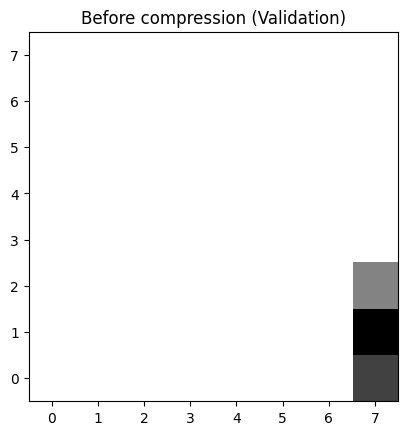

After compression (Validation)
Shape: (1, 8, 8)


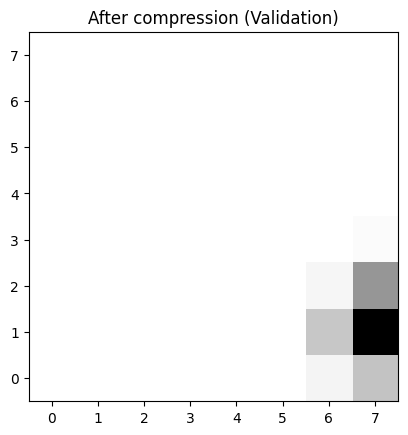

----------------------------------------
Patch = 0 compression results
----------------width_val------------------------
Patch encoder output encoded into:codebook indexes = 1
Compression ratio = 3.797140064324904
total_hit_amount = 48169
total_hit_bits = 1204225
patch_amount = 15857
encoded_patch_bits = 20.0 (1 patch 8 x 8)
num_embeddings = 512
Codebook dimensions: 512 x 32
----------------------------------------
Before compression (Validation)
Shape: (1, 8, 8)


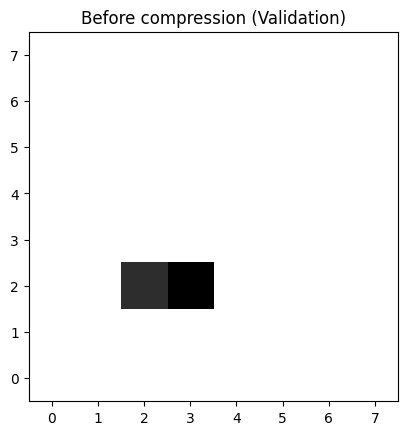

After compression (Validation)
Shape: (1, 8, 8)


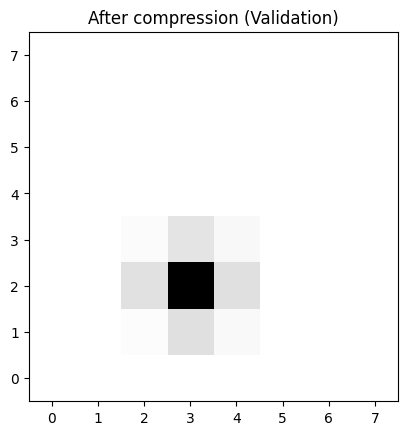

----------------------------------------
Patch = 1 compression results
----------------width_val------------------------
Patch encoder output encoded into:codebook indexes = 1
Compression ratio = 3.797140064324904
total_hit_amount = 48169
total_hit_bits = 1204225
patch_amount = 15857
encoded_patch_bits = 20.0 (1 patch 8 x 8)
num_embeddings = 512
Codebook dimensions: 512 x 32
----------------------------------------
Before compression (Validation)
Shape: (1, 8, 8)


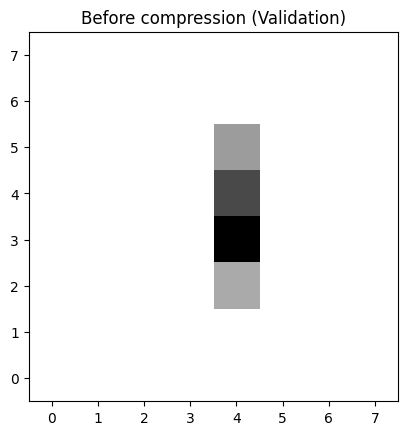

After compression (Validation)
Shape: (1, 8, 8)


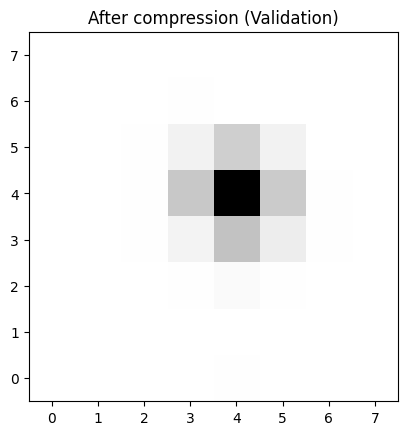

----------------------------------------
Patch = 2 compression results
----------------width_val------------------------
Patch encoder output encoded into:codebook indexes = 1
Compression ratio = 3.797140064324904
total_hit_amount = 48169
total_hit_bits = 1204225
patch_amount = 15857
encoded_patch_bits = 20.0 (1 patch 8 x 8)
num_embeddings = 512
Codebook dimensions: 512 x 32
----------------------------------------
Before compression (Validation)
Shape: (1, 8, 8)


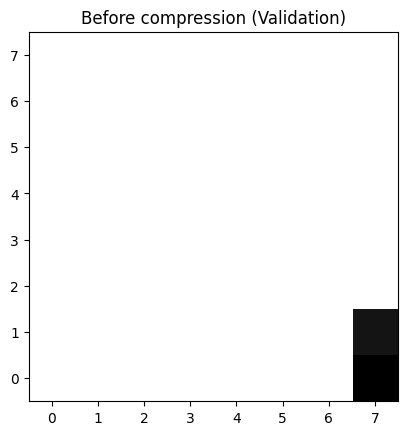

After compression (Validation)
Shape: (1, 8, 8)


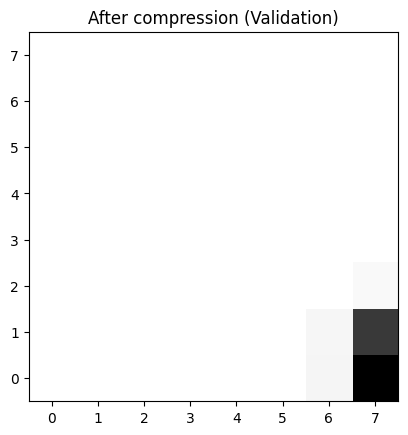

----------------------------------------
Patch = 3 compression results
----------------width_val------------------------
Patch encoder output encoded into:codebook indexes = 1
Compression ratio = 3.797140064324904
total_hit_amount = 48169
total_hit_bits = 1204225
patch_amount = 15857
encoded_patch_bits = 20.0 (1 patch 8 x 8)
num_embeddings = 512
Codebook dimensions: 512 x 32
----------------------------------------
Before compression (Validation)
Shape: (1, 8, 8)


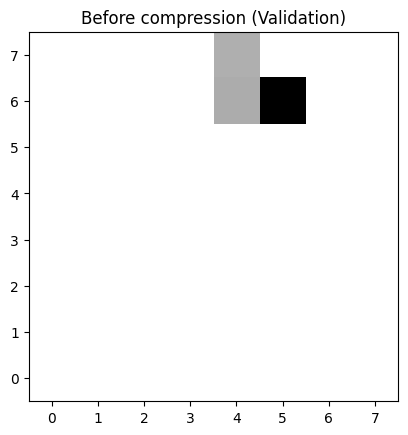

After compression (Validation)
Shape: (1, 8, 8)


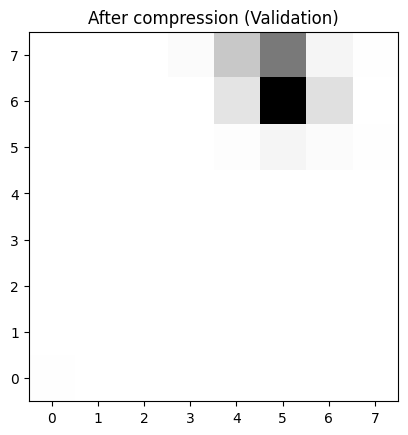

----------------------------------------
Patch = 4 compression results
----------------width_val------------------------
Patch encoder output encoded into:codebook indexes = 1
Compression ratio = 3.797140064324904
total_hit_amount = 48169
total_hit_bits = 1204225
patch_amount = 15857
encoded_patch_bits = 20.0 (1 patch 8 x 8)
num_embeddings = 512
Codebook dimensions: 512 x 32
----------------------------------------
Before compression (Validation)
Shape: (1, 8, 8)


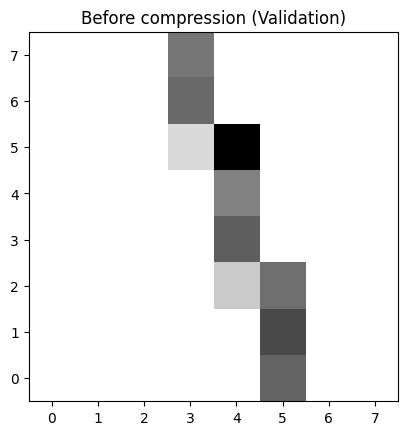

After compression (Validation)
Shape: (1, 8, 8)


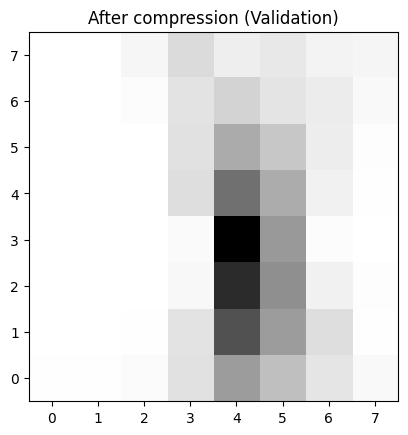

----------------------------------------
Patch = 5 compression results
----------------width_val------------------------
Patch encoder output encoded into:codebook indexes = 1
Compression ratio = 3.797140064324904
total_hit_amount = 48169
total_hit_bits = 1204225
patch_amount = 15857
encoded_patch_bits = 20.0 (1 patch 8 x 8)
num_embeddings = 512
Codebook dimensions: 512 x 32
----------------------------------------
Before compression (Validation)
Shape: (1, 8, 8)


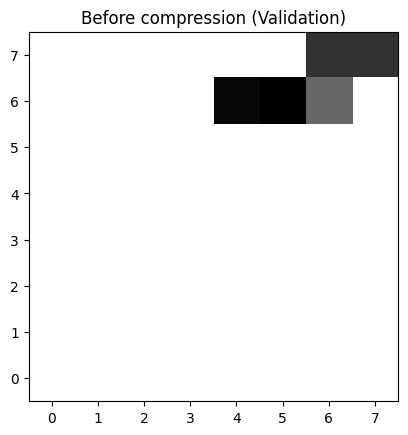

After compression (Validation)
Shape: (1, 8, 8)


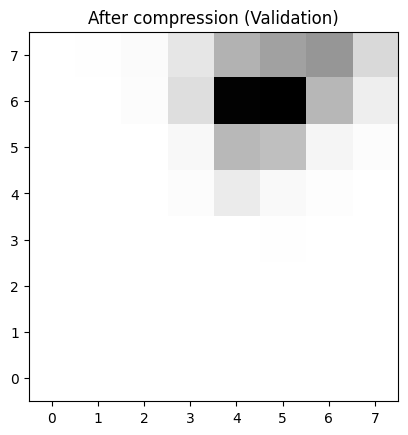

----------------------------------------
Patch = 6 compression results
----------------width_val------------------------
Patch encoder output encoded into:codebook indexes = 1
Compression ratio = 3.797140064324904
total_hit_amount = 48169
total_hit_bits = 1204225
patch_amount = 15857
encoded_patch_bits = 20.0 (1 patch 8 x 8)
num_embeddings = 512
Codebook dimensions: 512 x 32
----------------------------------------
Saving trained model VQ-VAE


In [23]:
# Running model hyperparameter validation 
for (plot_idx, patch_val) in enumerate(val_loader):
    patch_val = patch_val.to(device)           
    patch_val = patch_val.float()
    (
        recon_patch_val, 
        codebook_val, 
        z_q_val, 
        perplexity_val,
        _, _, _
    ) = model(patch_val, d)
    
    print("Before compression (Validation)")                    
    patch_val_ts_val = model_tool._tensor_to_numpy(
        patch_val.squeeze(1)
    )
    
    print(f"Shape: {patch_val_ts_val.shape}")            
    cms_plots.plot_patch(patch_val_ts_val[0], "Before compression (Validation)")
    
    patches_before_val.append(patch_val_ts_val[0])
    
    recon_patch_np_val = model_tool._tensor_to_numpy(
        recon_patch_val[0]
    )
    print("After compression (Validation)")
    print(f"Shape: {recon_patch_np_val.shape}")
    
    cms_plots.plot_patch(
        recon_patch_np_val[0], 
        "After compression (Validation)"
    )

    patches_after_val.append(recon_patch_np_val[0])  
    encodings_val_np = model_tool._tensor_to_numpy(codebook_val)
    patches_encodings_val.append(encodings_val_np) 
    
    batch, indexes_enc, channel = z_q_val.shape
    c_width, c_height = codebook_val.shape
    
    print("----------------------------------------")
    print(f"Patch = {plot_idx} compression results")
    print("----------------width_val------------------------")
    print(
        f"Patch encoder output encoded into:"
        f"codebook indexes = {indexes_enc}"
    )
    

    compression_ratio = cms_data_tool._get_compression_ratio(
        n_hits_total=total_hit_amount,
        patch_amount=patch_amount,
        encoded_patch_size=(d, num_embeddings),
        patch_size=PATCH_SIZE
    )
    total_bits = cms_data_tool._get_total_hit_bits(total_hit_amount)
    encoded_patch_bits = cms_data_tool._get_encoded_patch_bits(
        (
            d,
            num_embeddings
        ), 
        PATCH_SIZE
    )
    
    print(f"Compression ratio = {compression_ratio}")
    print(f"total_hit_amount = {total_hit_amount}")
    print(f"total_hit_bits = {total_bits}")
    print(f"patch_amount = {patch_amount}")
    print(f"encoded_patch_bits = {encoded_patch_bits} (1 patch {PATCH_SIZE} x {PATCH_SIZE})")
    print(f"num_embeddings = {num_embeddings}")
    print(f"Codebook dimensions: {c_width} x {c_height}")
    print("----------------------------------------")


# save model
print("Saving trained model VQ-VAE")
torch.save(model.state_dict(), "../bin/vqvae.pth")

In [24]:
print("Before saving")
print(model.vq_layer.codebook.norm())
print(model.vq_layer.ema_weights.norm())
print(model.vq_layer.ema_cluster_size.sum())  

Before saving
tensor(33.3335, device='cuda:0', grad_fn=<LinalgVectorNormBackward0>)
tensor(324.4278, device='cuda:0')
tensor(972.8085, device='cuda:0')


<h3>VQ-VAE results analysis</h3>

In [25]:
total_bits = cms_data_tool._get_total_hit_bits(
    total_hit_amount
)


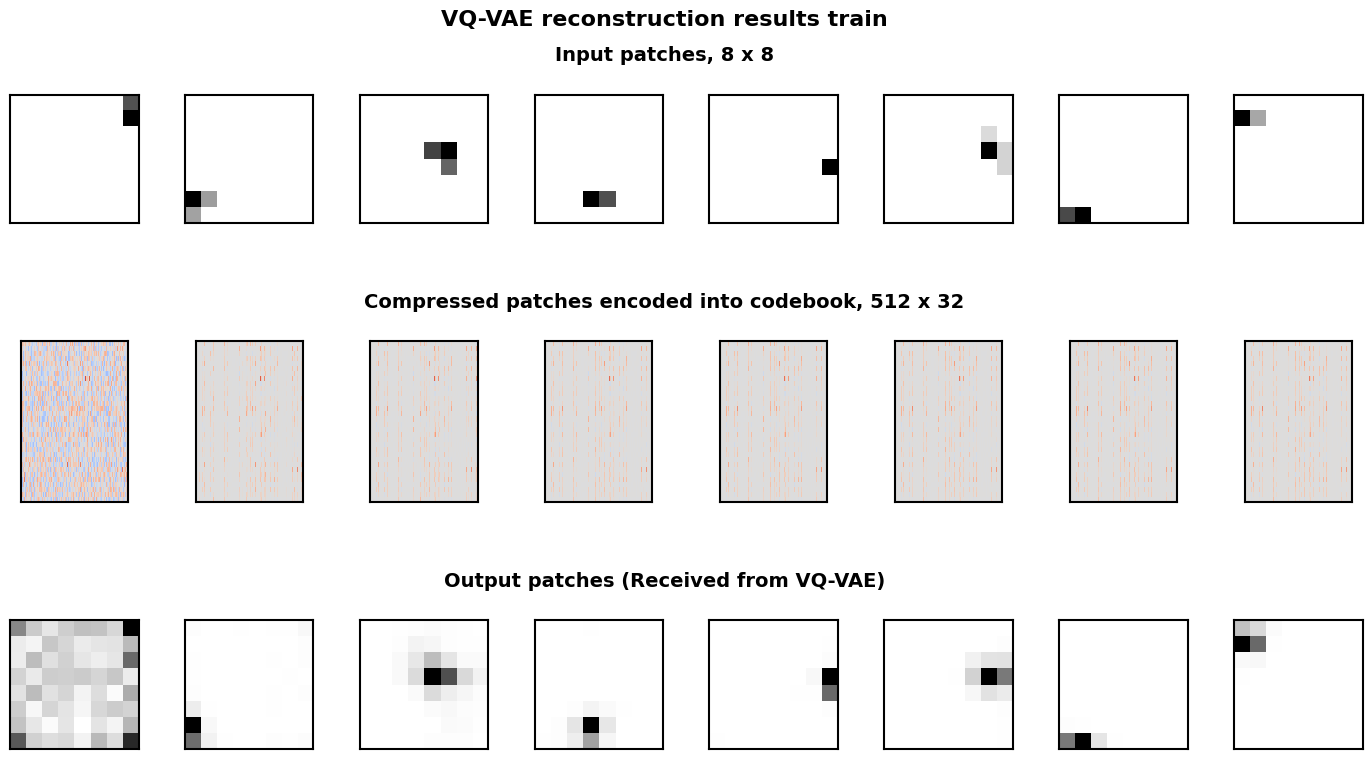

In [26]:
patch_rows = [
    (patches_before_train, "Input patches, 8 x 8"),
    (
        patches_encodings_train, 
        f"Compressed patches encoded into codebook, {num_embeddings} x {latent_dim}"
    ),
    (patches_after_train, "Output patches (Received from VQ-VAE)")
]

cms_plots.plot_patches(patch_rows, "VQ-VAE reconstruction results train")

# NOTE: Some patches are blurry due to early collection in the epochs

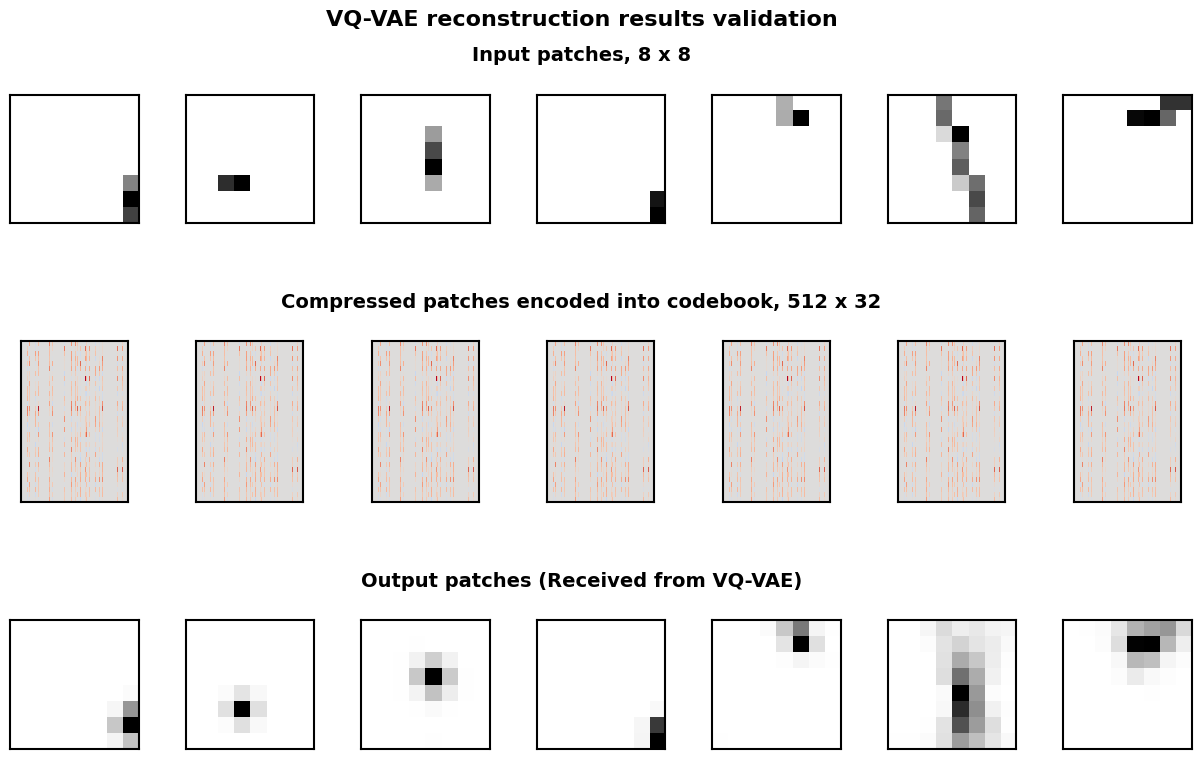

In [27]:
try:
    patch_rows = [
        (patches_before_val, "Input patches, 8 x 8"),
        (patches_encodings_val, 
        f"Compressed patches encoded into codebook, {num_embeddings} x {latent_dim}"
        ),
        (patches_after_val, "Output patches (Received from VQ-VAE)")
    ]

    cms_plots.plot_patches(
        patch_rows, 
        "VQ-VAE reconstruction results validation"
    )
except Exception as error:
    print(error)

In [28]:
# TODO
# Improve gradients
model_tool._display_gradients(model)

Showing model gradients
encoder.0.weight 0.0034517182502895594
encoder.1.weight 0.0004186609003227204
encoder.1.bias 0.0005679515888914466
encoder.3.weight 0.013100230135023594
encoder.4.weight 0.00037881534080952406
encoder.4.bias 0.0004081481311004609
encoder.6.weight 0.017258165404200554
encoder.7.weight 0.00036556049599312246
encoder.7.bias 0.0006865840405225754
encoder.8.stack.0.res_block.1.weight 0.004469902720302343
encoder.8.stack.0.res_block.3.weight 0.0016705020098015666
encoder.8.stack.1.res_block.1.weight 0.0053552561439573765
encoder.8.stack.1.res_block.3.weight 0.0019317351980134845
fc_encoder_input.layers.0.weight 0.0022064095828682184
fc_encoder_input.layers.0.bias 4.94765117764473e-10
fc_encoder_input.layers.1.weight 0.0012379058171063662
fc_encoder_input.layers.1.bias 0.0022937499452382326
fc_decoder_input.layers.0.weight 0.0005983192240819335
fc_decoder_input.layers.0.bias 0.001651096623390913
fc_decoder_input.layers.1.weight 0.0012114807032048702
fc_decoder_input.la

VQ VAE, BCE encoder average loss values over epochs


/home/paulius/vq_vae_experiments/helpers/data_tool.py:122: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


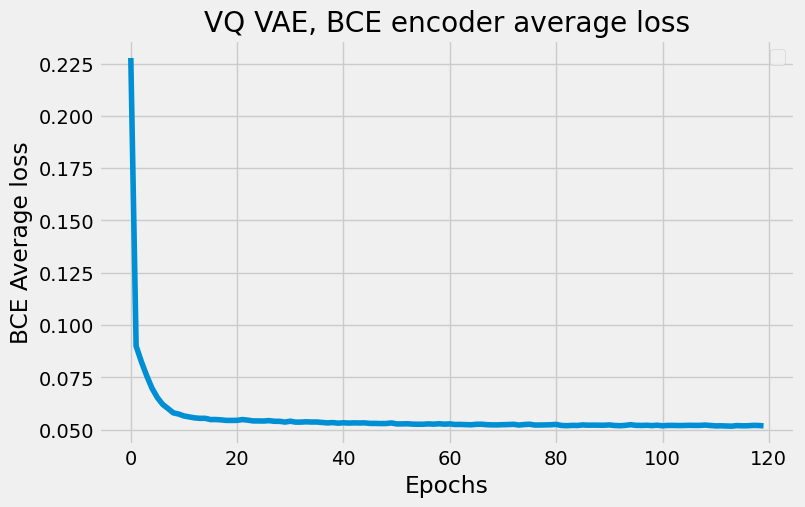

Saved VQ-VAE loss train data to csv
Saved VQ-VAE loss validation data to csv


In [29]:
# display loss values
cms_plots.plot_curve(
    y_values=average_loss_train, 
    x_values=list(range(num_epochs)),
    y_title="BCE Average loss",
    title="VQ VAE, BCE encoder average loss",
    x_label="Epochs"
)

# Saving train loss data
data_csv = pd.DataFrame(
    {
        "vq_average_loss" : average_loss_train,
        "bce_average_train_loss" : average_loss_train_bce,
        "mse_average_train_loss" : average_loss_train_mse,
        "epochs" : list(range(num_epochs))        
    }
)
data_csv.to_csv("vqvae_average_train.csv",index=False)
print("Saved VQ-VAE loss train data to csv")

# Saving validation loss data
data_csv = pd.DataFrame(
    {
        "bce_average_val_loss" : average_loss_values_val,
        "mse_average_val_loss" : average_loss_valid_mse_val,
        "epochs" : list(range(num_epochs))        
    }
)
data_csv.to_csv("vqvae_average_val.csv",index=False)
print("Saved VQ-VAE loss validation data to csv")


In [30]:
# Test set for testing using unseen data
debug_1_patch = True
model.load_state_dict(torch.load("../bin/vqvae.pth"))
model.eval()

print("After saving")
print(model.vq_layer.codebook.norm())
print(model.vq_layer.ema_weights.norm())
print(model.vq_layer.ema_cluster_size.sum())  

bce_loss_values_test = []

patch_display_limit = 6
patches_after_test = []
patches_before_test = []
patches_encodings_test = [] # latent vector

bce_total_value = 0
perplexity_total = 0
test_set_size = len(test_loader)

for patch_test in test_loader:
    patch_test = patch_test.to(device)                     
    (
        recon_patch, 
        codebook_test, 
        z_q, 
        perplexity,
        _, usage, encodings
    ) = model(patch_test, d)
    
    perplexity_total += perplexity.item()
    
    if len(patches_after_test) < patch_display_limit:
        patch_test_np = patch_test[0][0].cpu().detach().numpy()
        patches_before_test.append(patch_test_np)
        
        recon_patch_np = recon_patch[0][0].cpu().detach().numpy()
        patches_after_test.append(recon_patch_np)
        patches_encodings_test.append(
            model_tool._tensor_to_numpy(codebook_test)
        )
    
    # mse_loss = F.mse_loss(patch_test, recon_patch).item()
    bce_loss = F.binary_cross_entropy(
        patch_test, 
        recon_patch, 
        reduction="mean"
    ).cpu().detach().numpy().item()
    
    bce_total_value += bce_loss
    
bce_loss_average = bce_total_value / test_set_size
perplexity_average = perplexity_total / test_set_size

print(f"Based on test set (size = {test_set_size}), average BCE loss = {bce_loss_average:.5f}")
print(f"Based on test set (size = {test_set_size}), average codebook perplexity = {perplexity_average:.5f}/{num_embeddings}")
print(f"Codebook usage: {usage} %")

if debug_1_patch:
    print(f"Codebook codeword learned indexes")
    values, counts = torch.unique(
        encodings,
        return_counts=True
    )

    print(values)
    print(counts)
    debug_1_patch = False

# saving
test_df_frame = pd.DataFrame(
    {
        "average_bce_loss_test" : [bce_loss_average],
        "average_perplexity_test" : [perplexity_average]
    }
)
test_df_frame.to_csv("vqvae_test_loss.csv")
print("Saved VQ-VAE test results")

After saving
tensor(33.3335, device='cuda:0', grad_fn=<LinalgVectorNormBackward0>)
tensor(324.4278, device='cuda:0')
tensor(972.8085, device='cuda:0')
Based on test set (size = 3165), average BCE loss = 0.82319
Based on test set (size = 3165), average codebook perplexity = 1.00000/512
Codebook usage: 0.1953125 %
Codebook codeword learned indexes
tensor([271], device='cuda:0')
tensor([1], device='cuda:0')
Saved VQ-VAE test results


In [31]:
len(patches_before_test)

6

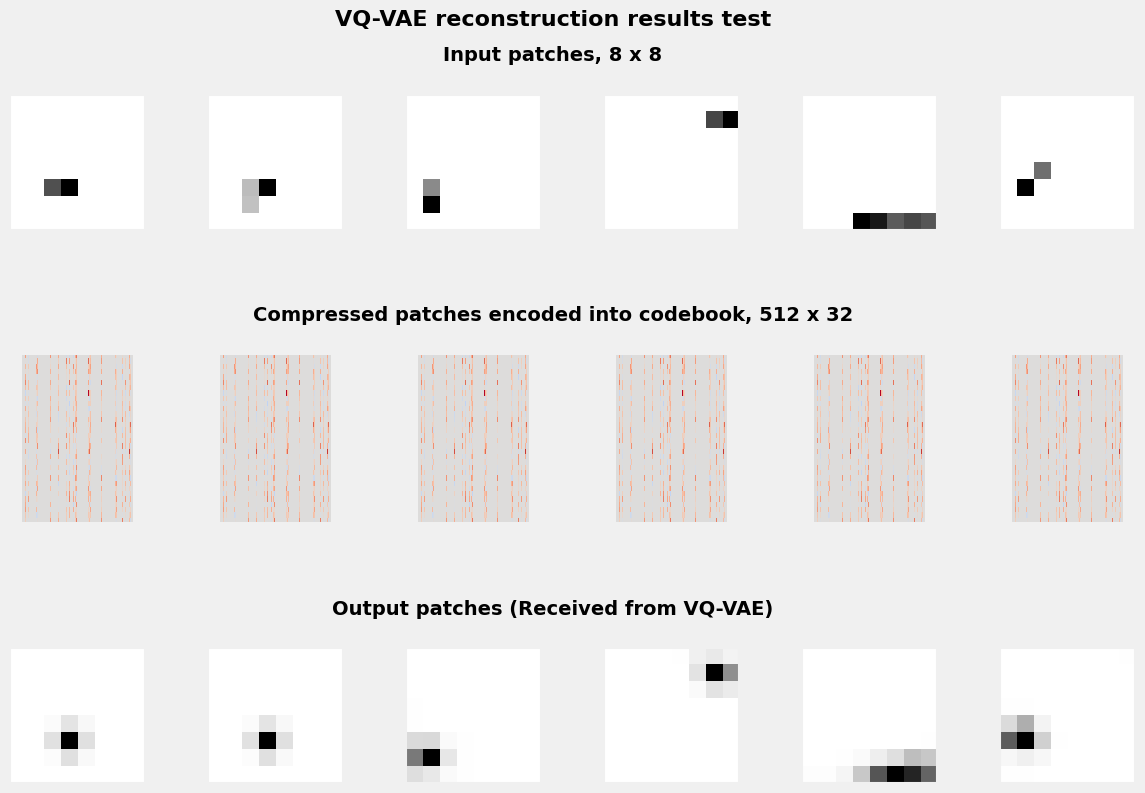

In [32]:
# Test dataset plotting part
patch_rows = [
    (patches_before_test, "Input patches, 8 x 8"),
    (patches_encodings_test, f"Compressed patches encoded into codebook, {num_embeddings} x {latent_dim}"),
    (patches_after_test, "Output patches (Received from VQ-VAE)")
]

cms_plots.plot_patches(patch_rows, "VQ-VAE reconstruction results test")

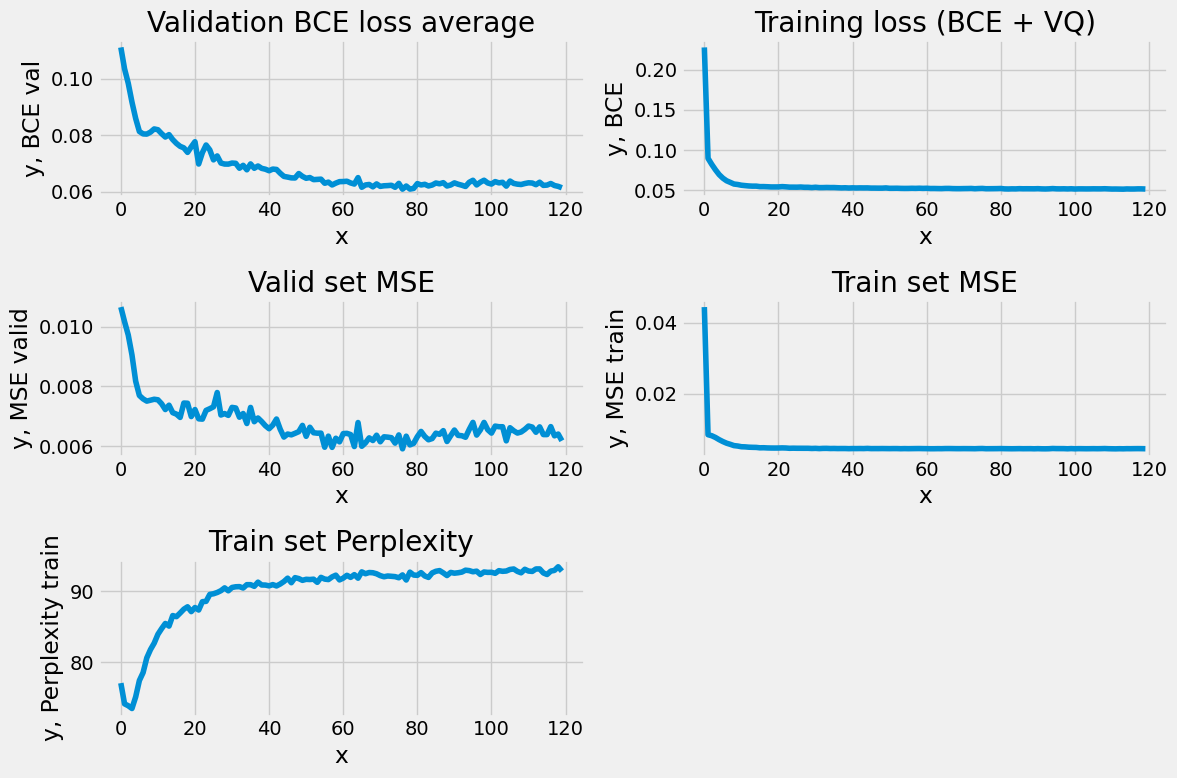

In [33]:
values_to_plot = [
    (list(range(len(average_loss_values_val))), average_loss_values_val, "Validation BCE loss average", "BCE val"),
    (list(range(len(average_loss_train))), average_loss_train, "Training loss (BCE + VQ)", "BCE"),
    (list(range(len(average_loss_valid_mse_val))), average_loss_valid_mse_val, "Valid set MSE", "MSE valid"),
    (list(range(len(average_loss_train_mse))), average_loss_train_mse, "Train set MSE", "MSE train"),
    (list(range(len(average_perplexity_train))), average_perplexity_train, "Train set Perplexity", "Perplexity train"),
]

cms_plots.plot_curves(values_to_plot)


In [34]:
# params = [
#     p for name, p in model.named_parameters()
#     if name != "vq.embedding.weight"
# ]
# params